In [1]:
#makemore part5开启！

In [2]:
#我们之前已经很大程度上优化了我们的神经网络
#但是我们的loss最低最低只能降到2左右
#这主要是因为我们的上下文就3个字符
#太小了，理论上我们很难实现很低的loss
#所以这一章我们来优化它
#上一章我们主要内容是手动推导backward，可以算是dlc支线任务
#现在我们回归主线，从part3导入初始化代码

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words=open("names.txt","r").read().splitlines()

chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
vocab_size=len(itos)

block_size=3

def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

In [4]:
#因为我们已经理解了神经网络的基本底层逻辑
#所以我们现在直接操作类就好了
class Linear:
    def __init__(self, fan_in, fan_out, bias=True): 
        self.weight = torch.randn((fan_in, fan_out)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight               
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):

        self.eps = eps
        self.momentum = momentum
        self.training = True                  

        self.gamma = torch.ones(dim)   
        self.beta = torch.zeros(dim)        

        self.running_mean = torch.zeros(dim)      
        self.running_var = torch.ones(dim)           

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)      
            xvar = x.var(0, keepdim=True)          
        else:
            xmean = self.running_mean          
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) 
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [5]:
#我们之前一直使用g作为随机数生成器
#其实torch本身可以实现全局的固定种子
torch.manual_seed(42);

In [6]:
n_embd=10
n_hidden=200

C=torch.randn((vocab_size,n_embd))
layers=[
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 12097


In [7]:
max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.2966
当前轮次:  10000/总轮次: 200000 loss=2.2322
当前轮次:  20000/总轮次: 200000 loss=2.4111
当前轮次:  30000/总轮次: 200000 loss=2.1004
当前轮次:  40000/总轮次: 200000 loss=2.3157
当前轮次:  50000/总轮次: 200000 loss=2.2104
当前轮次:  60000/总轮次: 200000 loss=1.9653
当前轮次:  70000/总轮次: 200000 loss=1.9767
当前轮次:  80000/总轮次: 200000 loss=2.6738
当前轮次:  90000/总轮次: 200000 loss=2.0837
当前轮次: 100000/总轮次: 200000 loss=2.2730
当前轮次: 110000/总轮次: 200000 loss=1.7087
当前轮次: 120000/总轮次: 200000 loss=2.3243
当前轮次: 130000/总轮次: 200000 loss=2.2512
当前轮次: 140000/总轮次: 200000 loss=2.0113
当前轮次: 150000/总轮次: 200000 loss=1.8195
当前轮次: 160000/总轮次: 200000 loss=1.7985
当前轮次: 170000/总轮次: 200000 loss=2.2206
当前轮次: 180000/总轮次: 200000 loss=2.0566
当前轮次: 190000/总轮次: 200000 loss=2.1030


In [8]:
for layer in layers:
    layer.training=False

train 2.0621414184570312
val 2.109346389770508


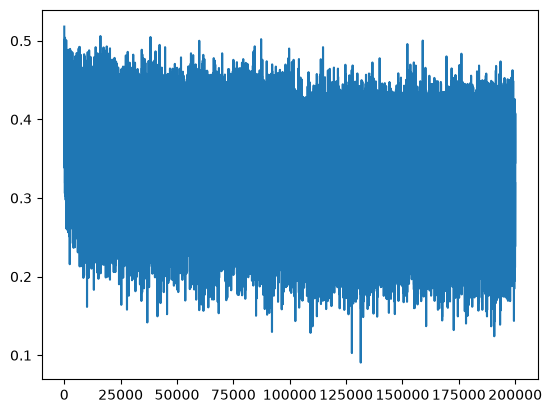

In [9]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(lossi)

In [10]:
#生成姓名
for i in range(20):
    context = [0] * block_size
    out = []
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

ivon.
fanili.
thoommasamiel.
emmadery.
andr.
aleigh.
kelynnie.
jazul.
carleen.
jah.
jorra.
alaya.
shonan.
vishylaharia.
juna.
vio.
orven.
meriell.
laiye.
zefina.


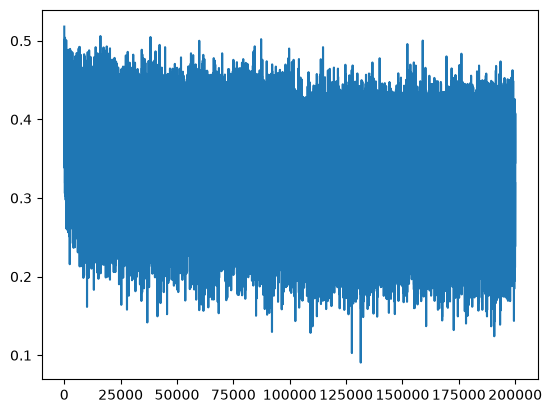

In [11]:
#接下来我们就要来优化我们的模型
#首先我们先来优化一下我们的图片
plt.plot(lossi)

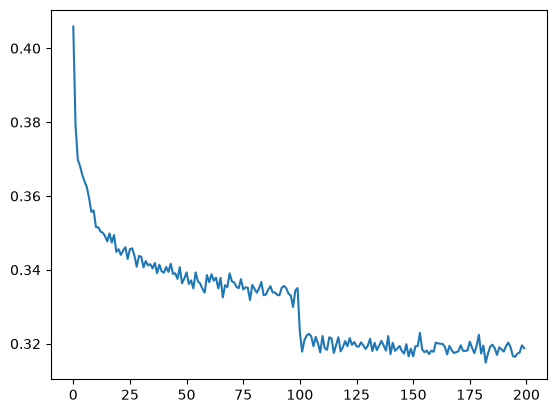

In [12]:
#这张图片反映不了任何信息，可以说就是一坨蓝色色块
#我们分片段取平均
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [13]:
#这样就能看出其实我们的模型进步明显，只不过之前的图太密集了
#中间还有一道很明显的下降是学习率的降低，让我们的模型可以稳定的下降

In [14]:
#接下来我们来优化下前向传播
# emb=C[Xb]
# x=emb.view(emb.shape[0],-1)
# for layer in layers:
#     x=layer(x)
# loss=F.cross_entropy(x,Yb)
#这段代码实在是冗余，我们的C没有被并入layers，还有一个view的环节，不好看不好看

In [15]:
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]


class Flatten:

  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []

In [16]:
#我们实现两个新的类，这样可以把他们给塞到layers里了
#而且这两个类也是在pytorch中有现成的实现，我们只是套用过来了

In [17]:
n_embd=10
n_hidden=200

layers=[
    Embedding(vocab_size,n_embd),Flatten(),
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

parameters=[p for layer in layers for p in layer.parameters()]
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    x=Xb
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

    if i>=1000:
        break

总参数量： 12097
当前轮次:      0/总轮次: 200000 loss=3.2763


In [18]:
#冒烟就行

In [19]:
#其实pytorch也实现了一个叫做container的东西
#这个东西的功能就和我们建立的layers是一样的，依次调用层
#而且我们的parameters功能也可以集成到这个里

In [20]:
class Sequential:
    def __init__(self,layers):
        self.layers=layers
        
    def __call__(self,x):      
        for layer in self.layers:
            x=layer(x)
        self.out=x
        return self.out

    def parameters(self):
        return[p for layer in self.layers for p in layer.parameters()]

In [ ]:
n_embd=10
n_hidden=200

layers=[
    Embedding(vocab_size,n_embd),Flatten(),
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

总参数量： 12097
当前轮次:      0/总轮次: 200000 loss=3.3080
当前轮次:  10000/总轮次: 200000 loss=2.0364
当前轮次:  20000/总轮次: 200000 loss=1.7232


In [ ]:
#更简洁了
#而且我们的验证和采样代码也可以简洁

In [ ]:
for layer in model.layers:
    layer.training=False

In [ ]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

In [ ]:
#生成姓名
for i in range(20):
    context = [0] * block_size
    out = []
    while True:
        logits=model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))